# 🔁 Cross-Validation with MLflow Tracking

**Purpose:** Learn cross-validation AND how to track experiments with MLflow.

**What you'll learn:**
- How to implement time-series cross-validation
- How to connect to AWS MLflow tracking server
- How to log metrics, parameters, and artifacts to MLflow
- How to organize CV experiments with nested runs

---

## 💡 Why MLflow?

**Problem without experiment tracking:**
- Hard to remember which hyperparameters produced which results
- Can't compare different model versions
- Results stored in notebooks that get lost or overwritten

**Solution: MLflow**
- Automatically logs all experiments
- Compare runs side-by-side
- Share results with team
- Reproduce any experiment

## 🔌 Connect to MLflow Server

First, we need to connect to the AWS SageMaker MLflow tracking server.

In [1]:
# Setup MLflow connection to AWS SageMaker
import os

# Clear any old settings
os.environ.pop("MLFLOW_REGISTRY_URI", None)

# Configure AWS MLflow
os.environ["AWS_PROFILE"] = "your-profile"  # Change this to your AWS profile
os.environ["AWS_REGION"] = "af-south-1"
os.environ["MLFLOW_TRACKING_URI"] = "arn:aws:sagemaker:af-south-1:733246370304:mlflow-tracking-server/dth-churn-ml"
os.environ["MLFLOW_REGISTRY_URI"] = "sqlite:///:memory:"

# Load MLflow plugin (must be BEFORE importing mlflow)
import sagemaker_mlflow

# Now import MLflow
import mlflow

print("✓ MLflow configured")
print(f"  Tracking URI: {mlflow.get_tracking_uri()}")
print(f"  Registry URI: {mlflow.get_registry_uri()}")

✓ MLflow configured
  Tracking URI: arn:aws:sagemaker:af-south-1:733246370304:mlflow-tracking-server/dth-churn-ml
  Registry URI: sqlite:///:memory:


## Import Libraries

In [2]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score
)
from catboost import Pool, CatBoostClassifier

# Set random seed
SEED = 42
np.random.seed(SEED)

print("✓ Libraries imported")

✓ Libraries imported


## Configuration

In [3]:
# Target and business requirements
TARGET_COL = "churn"
TARGET_RECALL = 0.80

# ID columns to drop
ID_COLS = ["idconsumo", "codigocontaservico", "idconta", "iddim_cliente", 
           "idcliente", "codigocliente", "iddim_conta", "codigoconta"]

# Cross-validation settings
N_FOLDS = 5

# MLflow experiment name
EXPERIMENT_NAME = "churn-cross-validation"

print(f"✓ Configuration:")
print(f"  Target: {TARGET_COL}")
print(f"  Target recall: {TARGET_RECALL:.0%}")
print(f"  Number of folds: {N_FOLDS}")
print(f"  MLflow experiment: {EXPERIMENT_NAME}")

✓ Configuration:
  Target: churn
  Target recall: 80%
  Number of folds: 5
  MLflow experiment: churn-cross-validation


## 1. Load Data

In [4]:
# Load data from data preparation notebook
DATA_DIR = "../2. Training/data_preparation_output"

train_df = pd.read_parquet(f"{DATA_DIR}/train.parquet")
val_df = pd.read_parquet(f"{DATA_DIR}/val.parquet")

# Combine for cross-validation (CV creates its own splits)
df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

print(f"✓ Loaded data:")
print(f"  Train: {len(train_df):,} rows")
print(f"  Val:   {len(val_df):,} rows")
print(f"  Total: {len(df):,} rows")
print(f"  Churn rate: {df[TARGET_COL].mean():.1%}")

✓ Loaded data:
  Train: 82,717 rows
  Val:   10,340 rows
  Total: 93,057 rows
  Churn rate: 36.9%


## 2. Prepare Features

In [5]:
# Drop ID columns
id_cols = [col for col in ID_COLS if col in df.columns]
df = df.drop(columns=id_cols)

# IMPORTANT: Convert date column and save it BEFORE dropping
date_col = 'iddim_date_inicio'
df[date_col] = pd.to_datetime(df[date_col])

# Sort by date for time-series CV
sort_order = df[date_col].argsort()
df = df.iloc[sort_order].reset_index(drop=True)

# Save the sorted date column for later (for visualization)
date_series = df[date_col].copy()

print(f"✓ Sorted by date")
print(f"  Date range: {df[date_col].min().date()} to {df[date_col].max().date()}")

# Separate features and target
y = df[TARGET_COL].values
X = df.drop(columns=[TARGET_COL])

# Drop ALL datetime columns (not just specific ones)
datetime_cols = X.select_dtypes(include=['datetime64']).columns.tolist()
# Also add known date columns that might be strings
for col in ['iddim_date_inicio', 'iddim_date_fim']:
    if col in X.columns and col not in datetime_cols:
        datetime_cols.append(col)

if datetime_cols:
    print(f"\\nDropping datetime columns: {datetime_cols}")
    X = X.drop(columns=datetime_cols)

# Identify categorical features
cat_features = X.select_dtypes(include=['object']).columns.tolist()
cat_indices = [X.columns.get_loc(col) for col in cat_features]

print(f"\\n✓ Prepared features:")
print(f"  {len(X.columns)} total features")
print(f"  {len(cat_features)} categorical features")
print(f"  {len(y):,} samples")

✓ Sorted by date
  Date range: 2021-02-08 to 2025-04-19
\nDropping datetime columns: ['iddim_date_inicio', 'iddim_date_fim', 'last_contact_ts']
\n✓ Prepared features:
  46 total features
  9 categorical features
  93,057 samples


## 3. Cross-Validation with MLflow Tracking

Now we'll run cross-validation and log everything to MLflow!

**MLflow structure:**
- **Parent run**: Overall CV experiment
- **Child runs**: One for each fold

This lets us see both individual fold results AND aggregated metrics.

In [6]:
# Set MLflow experiment
mlflow.set_experiment(EXPERIMENT_NAME)

# Create TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=N_FOLDS)

# Store results
fold_results = []
fold_dates = []

print(f"Starting {N_FOLDS}-fold cross-validation with MLflow tracking...")
print(f"Training on PAST → Validating on FUTURE\n")

# Ensure no active MLflow run remains open
try:
    if mlflow.active_run():
        mlflow.end_run()
except Exception as _:
    pass

# Start parent MLflow run for the entire CV experiment
with mlflow.start_run(run_name="cv-time-series-5fold") as parent_run:
    # Expose parent run id for later (e.g., artifact logging without reopening the run)
    PARENT_RUN_ID = parent_run.info.run_id
    
    # Log parent run parameters (overall CV settings)
    mlflow.log_param("cv_method", "TimeSeriesSplit")
    mlflow.log_param("n_folds", N_FOLDS)
    mlflow.log_param("target_recall", TARGET_RECALL)
    mlflow.log_param("total_samples", len(y))
    mlflow.log_param("n_features", len(X.columns))
    
    # Log model hyperparameters
    mlflow.log_param("model", "CatBoost")
    mlflow.log_param("iterations", 811)
    mlflow.log_param("learning_rate", 0.044)
    mlflow.log_param("depth", 5)
    mlflow.log_param("l2_leaf_reg", 1.015)
    
    # Loop through folds
    for fold_num, (train_idx, val_idx) in enumerate(tscv.split(X), start=1):
        
        print(f"Fold {fold_num}/{N_FOLDS}...")
        
        # Start child MLflow run for this fold
        with mlflow.start_run(run_name=f"fold-{fold_num}", nested=True):
            
            # Split data
            X_train = X.iloc[train_idx]
            X_val = X.iloc[val_idx]
            y_train = y[train_idx]
            y_val = y[val_idx]
            
            # Log fold info
            mlflow.log_param("fold", fold_num)
            mlflow.log_param("train_size", len(train_idx))
            mlflow.log_param("val_size", len(val_idx))
            
            # Save date ranges using the date_series we saved earlier
            train_dates = date_series.iloc[train_idx]
            val_dates = date_series.iloc[val_idx]
            fold_dates.append({
                'fold': fold_num,
                'train_start': train_dates.min(),
                'train_end': train_dates.max(),
                'val_start': val_dates.min(),
                'val_end': val_dates.max()
            })
            
            # Train model
            train_pool = Pool(X_train, y_train, cat_features=cat_indices)
            val_pool = Pool(X_val, y_val, cat_features=cat_indices)
            
            model = CatBoostClassifier(
                iterations=811,
                learning_rate=0.044,
                depth=5,
                l2_leaf_reg=1.015,
                random_seed=SEED,
                verbose=False,
                eval_metric='PRAUC'
            )
            
            model.fit(train_pool, eval_set=val_pool, use_best_model=True, early_stopping_rounds=50)
            
            # Get predictions
            y_val_proba = model.predict_proba(val_pool)[:, 1]
            
            # Calculate metrics
            roc_auc = roc_auc_score(y_val, y_val_proba)
            pr_auc = average_precision_score(y_val, y_val_proba)
            
            # Find threshold for target recall
            precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
            idx = np.where(recalls[:-1] >= TARGET_RECALL)[0]
            
            if len(idx) > 0:
                idx = idx[-1]
                threshold = thresholds[idx]
                precision = precisions[idx]
                recall = recalls[idx]
            else:
                threshold = 0.5
                y_val_pred = (y_val_proba >= threshold).astype(int)
                precision = precision_score(y_val, y_val_pred)
                recall = recall_score(y_val, y_val_pred)
            
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
            
            # Log metrics to MLflow
            mlflow.log_metric("roc_auc", roc_auc)
            mlflow.log_metric("pr_auc", pr_auc)
            mlflow.log_metric("precision", precision)
            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1", f1)
            mlflow.log_metric("threshold", threshold)
            
            # Save results
            fold_results.append({
                'fold': fold_num,
                'roc_auc': roc_auc,
                'pr_auc': pr_auc,
                'threshold': threshold,
                'precision': precision,
                'recall': recall,
                'f1': f1,
                'train_size': len(train_idx),
                'val_size': len(val_idx)
            })
            
            print(f"  Train: {len(train_idx):,} | Val: {len(val_idx):,}")
            print(f"  ROC-AUC: {roc_auc:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
            print(f"  ✓ Logged to MLflow\n")
    
    # Calculate and log aggregated metrics to parent run
    results_df = pd.DataFrame(fold_results)
    
    for metric in ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']:
        mean_val = results_df[metric].mean()
        std_val = results_df[metric].std()
        cv = std_val / mean_val if mean_val > 0 else 0
        
        mlflow.log_metric(f"{metric}_mean", mean_val)
        mlflow.log_metric(f"{metric}_std", std_val)
        mlflow.log_metric(f"{metric}_cv", cv)
    
    # Save results table as artifact
    results_df.to_csv("cv_results.csv", index=False)
    mlflow.log_artifact("cv_results.csv")
    
    print("\n✓ Cross-validation complete!")
    print(f"\n📊 View results in MLflow UI:")
    print(f"   {mlflow.get_tracking_uri()}")

Starting 5-fold cross-validation with MLflow tracking...
Training on PAST → Validating on FUTURE

Fold 1/5...
  Train: 15,512 | Val: 15,509
  ROC-AUC: 0.7368 | Precision: 0.5478 | Recall: 0.8000
  ✓ Logged to MLflow

🏃 View run fold-1 at: https://af-south-1.experiments.sagemaker.aws/#/experiments/2/runs/c429ea6cbf8b481688bf8594342a1a3c
🧪 View experiment at: https://af-south-1.experiments.sagemaker.aws/#/experiments/2
Fold 2/5...
  Train: 31,021 | Val: 15,509
  ROC-AUC: 0.7640 | Precision: 0.5315 | Recall: 0.8001
  ✓ Logged to MLflow

🏃 View run fold-2 at: https://af-south-1.experiments.sagemaker.aws/#/experiments/2/runs/5f5ca697d5cd4029a3e16d4e452fcd31
🧪 View experiment at: https://af-south-1.experiments.sagemaker.aws/#/experiments/2
Fold 3/5...
  Train: 46,530 | Val: 15,509
  ROC-AUC: 0.7686 | Precision: 0.5148 | Recall: 0.8001
  ✓ Logged to MLflow

🏃 View run fold-3 at: https://af-south-1.experiments.sagemaker.aws/#/experiments/2/runs/0e3670f5eade4681bb487d2c824596c7
🧪 View experimen

## 4. Visualize Temporal Splits

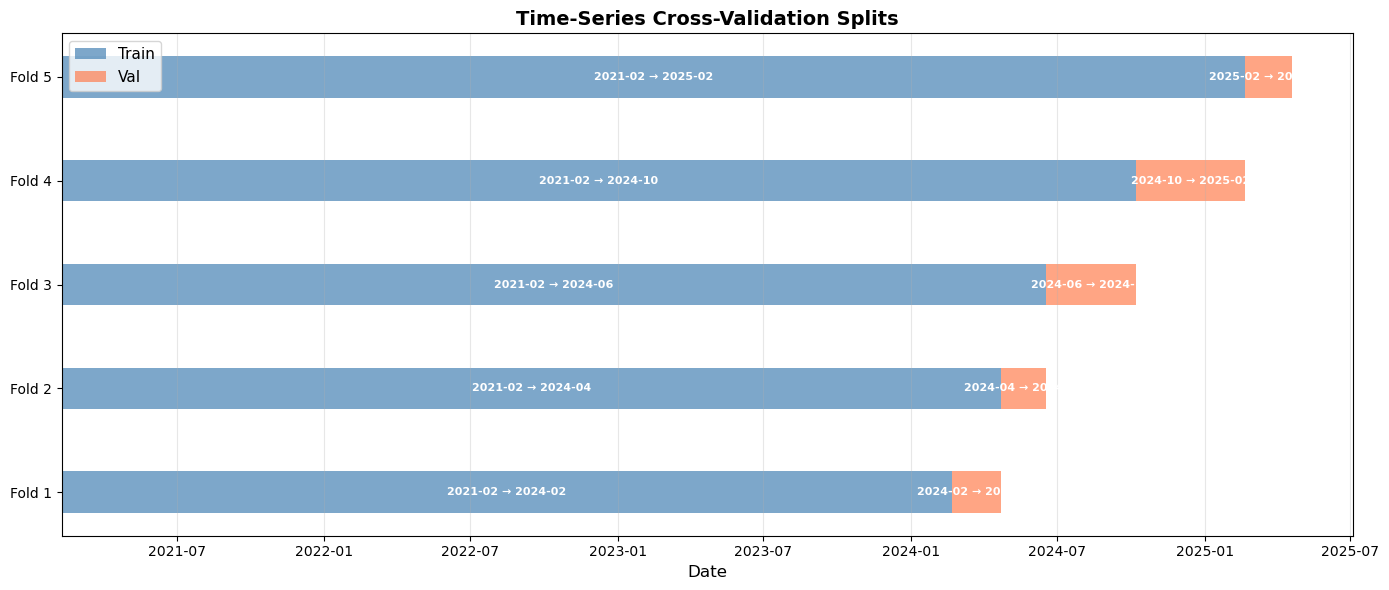


✓ Visualization saved and logged to MLflow (parent run)


In [7]:
# Visualize how we split the data by time
fig, ax = plt.subplots(figsize=(14, 6))

for fold_info in fold_dates:
    fold_num = fold_info['fold']
    
    # Training period (blue)
    train_days = (fold_info['train_end'] - fold_info['train_start']).days
    ax.barh(fold_num, train_days, left=fold_info['train_start'], 
            height=0.4, color='steelblue', alpha=0.7,
            label='Train' if fold_num == 1 else '')
    
    # Validation period (orange)
    val_days = (fold_info['val_end'] - fold_info['val_start']).days
    ax.barh(fold_num, val_days, left=fold_info['val_start'],
            height=0.4, color='coral', alpha=0.7,
            label='Val' if fold_num == 1 else '')
    
    # Add date labels
    train_mid = fold_info['train_start'] + (fold_info['train_end'] - fold_info['train_start']) / 2
    val_mid = fold_info['val_start'] + (fold_info['val_end'] - fold_info['val_start']) / 2
    ax.text(train_mid, fold_num, 
            f"{fold_info['train_start'].strftime('%Y-%m')} → {fold_info['train_end'].strftime('%Y-%m')}", 
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax.text(val_mid, fold_num,
            f"{fold_info['val_start'].strftime('%Y-%m')} → {fold_info['val_end'].strftime('%Y-%m')}", 
            ha='center', va='center', fontsize=8, color='white', fontweight='bold')

ax.set_yticks(range(1, N_FOLDS + 1))
ax.set_yticklabels([f'Fold {i}' for i in range(1, N_FOLDS + 1)])
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Time-Series Cross-Validation Splits', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('cv_temporal_splits.png', dpi=100, bbox_inches='tight')
plt.show()

# Log visualization to MLflow without reopening the (finished) parent run
try:
    from mlflow.tracking import MlflowClient
    client = MlflowClient()
    if 'PARENT_RUN_ID' in globals() and PARENT_RUN_ID:
        client.log_artifact(PARENT_RUN_ID, 'cv_temporal_splits.png')
        print("\n✓ Visualization saved and logged to MLflow (parent run)")
    else:
        print("\n⚠️ PARENT_RUN_ID not found; skipping MLflow artifact logging")
except Exception as e:
    print(f"\n⚠️ Failed to log artifact to MLflow: {e}")

## 5. Summary Statistics

In [8]:
# Display results
print("📊 Cross-Validation Results:\n")
print(results_df.to_string(index=False))

print("\n📈 Summary Statistics:\n")
metrics = ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']
for metric in metrics:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    min_val = results_df[metric].min()
    max_val = results_df[metric].max()
    print(f"  {metric.upper():12s}: {mean_val:.4f} ± {std_val:.4f}  (range: {min_val:.4f} - {max_val:.4f})")

📊 Cross-Validation Results:

 fold  roc_auc   pr_auc  threshold  precision   recall       f1  train_size  val_size
    1 0.736828 0.647153   0.402707   0.547807 0.800031 0.650319       15512     15509
    2 0.764031 0.631543   0.335413   0.531485 0.800139 0.638711       31021     15509
    3 0.768590 0.618649   0.317827   0.514757 0.800149 0.626481       46530     15509
    4 0.759907 0.613467   0.305232   0.512218 0.800073 0.624574       62039     15509
    5 0.769547 0.591900   0.261133   0.476598 0.800000 0.597335       77548     15509

📈 Summary Statistics:

  ROC_AUC     : 0.7598 ± 0.0134  (range: 0.7368 - 0.7695)
  PR_AUC      : 0.6205 ± 0.0206  (range: 0.5919 - 0.6472)
  PRECISION   : 0.5166 ± 0.0265  (range: 0.4766 - 0.5478)
  RECALL      : 0.8001 ± 0.0001  (range: 0.8000 - 0.8001)
  F1          : 0.6275 ± 0.0198  (range: 0.5973 - 0.6503)


## 6. Model Stability Analysis

In [9]:
print("📊 Model Stability (Coefficient of Variation):\n")

for metric in ['roc_auc', 'pr_auc', 'precision', 'recall', 'f1']:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std()
    cv = std_val / mean_val if mean_val > 0 else 0
    
    stability = "✓ Stable" if cv < 0.05 else "⚠️ Unstable"
    print(f"  {metric.upper():12s}: CV = {cv:.4f}  {stability}")

print("\n💡 Interpretation:")
print("  - CV < 0.05: Model is stable (good!)")
print("  - CV > 0.05: Model is unstable (investigate further)")

📊 Model Stability (Coefficient of Variation):

  ROC_AUC     : CV = 0.0176  ✓ Stable
  PR_AUC      : CV = 0.0333  ✓ Stable
  PRECISION   : CV = 0.0514  ⚠️ Unstable
  RECALL      : CV = 0.0001  ✓ Stable
  F1          : CV = 0.0315  ✓ Stable

💡 Interpretation:
  - CV < 0.05: Model is stable (good!)
  - CV > 0.05: Model is unstable (investigate further)


---
## 🎓 Key Takeaways

### Cross-Validation
1. **TimeSeriesSplit prevents data leakage** - Always train on past, validate on future
2. **Multiple folds = more reliable** - Get mean ± std instead of single score
3. **Check stability with CV** - CV = std/mean < 0.05 is good

### MLflow Tracking
1. **Nested runs** - Parent run for overall CV, child runs for each fold
2. **Log everything** - Parameters, metrics, artifacts
3. **Compare experiments** - View all runs in MLflow UI
4. **Reproducibility** - Every experiment is saved automatically

## 💡 MLflow Benefits

- **Never lose results** - All experiments saved permanently
- **Easy comparison** - Side-by-side comparison in UI
- **Team collaboration** - Share experiments with colleagues
- **Production ready** - Track model lineage from training to deployment

## 🚀 Next Steps

1. **Explore MLflow UI** - View all your experiments and runs
2. **Compare different hyperparameters** - Run CV with different settings
3. **Register best model** - Promote to model registry for deployment
4. **Set up CI/CD** - Automate model training and tracking